# 1. Set up

In [1]:
!pip install pandas
!pip install polars
!pip install scikit-learn
!pip install pyarrow
!pip install torch
!pip install xgboost category_encoders scikit-plot

# 2. Import necessary libraries

In [2]:
import pandas as pd
import polars as pl
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
import category_encoders as ce
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# 3. Define global variables

In [3]:
INPUT_EVENTOS_FRAUDE_PATH = "eventos_fraude_fecha_fin_anomalia_al_31_03_2025.csv"
INPUT_EVENTOS_CONTROL_PATH = "eventos_control_al_31_03_2025.csv"
INPUT_CONSUMOS_FRAUDE_PATH = "consumos_fraude_fecha_fin_anomalia_al_31_03_2025.csv"
INPUT_CONSUMOS_CONTROL_PATH = "consumos_control_al_31_03_2025.csv"
INPUT_CONTADORES_PATH = "contadores_al_31_05_2025.csv"
INPUT_FRAUDES_PATH = "fraudes_al_31_03_2025_fecha_fin.csv"

In [4]:
train_losses = list()

# 4. Functions

In [5]:
# nn.Module is the baseline of every model in PyTorch
class Autoencoder(nn.Module):
    def __init__(self, input_dim: int):
        # with super() we initialize the object nn.Module
        super().__init__()
        # We define the decoder that goes little by little reducing the dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), # 64 neurons for the first layer
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,32), # 32 neurons for the second layer
            nn.ReLU(),
            nn.Linear(32, 16)
            
        )
        # We define the decoder that goes little by little upgrading the dim. Reconstruction part
        self.decoder = nn.Sequential(
            nn.Linear(16, 32), 
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64,input_dim)
        )

    def forward(self, x):
        """
        Forward method that defines how the information flows. It just simply applys the encoder-decoder
        architecture.
        """
        z = self.encoder(x)
        return self.decoder(z)

In [6]:
def crear_pivot_detallado(df: pd.DataFrame, 
                          columnas_inspecciones: list,
                          columnas_eventos: list) -> pd.DataFrame:
    """
    Crea un pivot manteniendo toda la información de conteos por combinación et-c
    """
    # Primero, crear una columna que combine et y c para identificar cada tipo de evento
    df_trabajo = df.copy()
    df_trabajo['tipo_evento'] = df_trabajo['et'].astype(str) + '_' + df_trabajo['c'].astype(str)
   
    # Crear el diccionario de agregación base
    agg_dict = {}
   
    # Para las columnas de inspecciones: tomar el primer valor (son iguales para cada grupo)
    for col in columnas_inspecciones:
        agg_dict[col] = 'first'
   
    # Para las columnas de eventos: necesitamos tratamiento especial
    # Las agregaremos después del groupby usando pivot
   
    # Primero hacer el groupby básico para las columnas de inspecciones
    resultado_base = df_trabajo.groupby(['cups_sgc', 'cnt_id']).agg(agg_dict).reset_index()
   
    # Ahora crear el pivot para las columnas de eventos manteniendo la granularidad
    eventos_pivot_list = []
   
    for col_evento in columnas_eventos:
        # Crear un pivot para cada columna de eventos
        pivot_temp = df_trabajo.pivot_table(
            index=['cups_sgc', 'cnt_id'],
            columns='tipo_evento',
            values=col_evento,
            aggfunc='sum',
            fill_value=0
        ).reset_index()
       
        # Renombrar las columnas para incluir el nombre de la columna original
        pivot_temp.columns = ['cups_sgc', 'cnt_id'] + [f"{col_evento}_{col}" for col in pivot_temp.columns[2:]]
       
        eventos_pivot_list.append(pivot_temp)
   
    # Unir todos los pivots de eventos
    resultado_eventos = eventos_pivot_list[0]
    for pivot in eventos_pivot_list[1:]:
        resultado_eventos = resultado_eventos.merge(
            pivot,
            on=['cups_sgc', 'cnt_id'],
            how='outer'
        )
   
    # Unir con el resultado base (inspecciones)
    resultado_final = resultado_base.merge(
        resultado_eventos,
        on=['cups_sgc', 'cnt_id'],
        how='outer'
    )
   
    return resultado_final

# 5. Code

## 5.1. Parte no supervisada

### 5.1.1. Data processing

In [7]:
pl.read_csv(INPUT_EVENTOS_CONTROL_PATH)

cups_sgc,cnt_id,et,c,cnt_eventos_semana_actual,cnt_eventos_semana_pasada,cnt_eventos_misma_semana_anio_pasado,cnt_eventos_mes_actual,cnt_eventos_mes_pasado,cnt_eventos_mismo_mes_anio_pasado,cnt_eventos_trimestre_actual,cnt_eventos_trimestre_pasado,cnt_eventos_mismo_trimestre_anio_pasado,cnt_eventos_anio_actual,cnt_eventos_anio_pasado,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,cnt_inspecciones_mismo_trimestre_anio_pasado,cnt_inspecciones_anio_actual,cnt_inspecciones_anio_pasado
str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""ES0022000001000074HK1P""","""ZIV0049764171""",5,null,0,1,0,9,8,0,37,16,1,37,22,0,0,0,0,0,0,0,0,0,0,27
"""ES0022000001000074HK1P""","""ZIV0049764171""",1,51,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,27
"""ES0022000001000074HK1P""","""ZIV0049764171""",1,24,0,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,27
"""ES0022000001000074HK1P""","""ZIV0049764171""",6,null,0,28,28,162,142,158,466,402,466,466,1835,0,0,0,0,0,0,0,0,0,0,27
"""ES0022000001000074HK1P""","""ZIV0049764171""",1,96,0,0,0,0,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,27
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ES0022000009127621HN1P""","""SOG0100063669""",3,19,0,0,0,0,1,0,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0
"""ES0022000009127621HN1P""","""SOG0100063669""",3,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""ES0022000009127621HN1P""","""SOG0100063669""",3,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
eventos_fraude = pl.read_csv(INPUT_EVENTOS_FRAUDE_PATH)
eventos_control = pl.read_csv(INPUT_EVENTOS_CONTROL_PATH)
consumos_fraude = pl.read_csv(INPUT_CONSUMOS_FRAUDE_PATH).drop(["tuvo_fraude_previo", "tuvo_fraude_reciente", "estado_fraude"])
consumos_control = pl.read_csv(INPUT_CONSUMOS_CONTROL_PATH).drop(["tuvo_fraude_previo", "tuvo_fraude_reciente", "estado_fraude"])
# contadores = pl.read_csv(INPUT_CONTADORES_PATH)
fraudes = pd.read_csv(INPUT_FRAUDES_PATH).rename(columns={"cups": "cups_sgc", "fraudes_en_90_dias": "target"})

# sólo hay que pivotar la tabla de eventos para después unirla con las de consumos

eventos = pl.concat([eventos_control, eventos_fraude])
consumos = pl.concat([consumos_control, consumos_fraude])

In [9]:
# Extraemos las columnas numéricas de la tabla eventos
columnas_eventos = [col for col in eventos.columns if col not in ['cups_sgc', 'cnt_id', 'et', 'c'] and "eventos" in col]
columnas_inspecciones = [col for col in eventos.columns if col not in ['cups_sgc', 'cnt_id', 'et', 'c'] and "inspecciones" in col]

# Debemos rellenar los nulos de las columnas 'c' y 'et' antes de crear 'tipo_evento'
eventos = eventos.with_columns([
    pl.col("c").fill_null("NA").cast(pl.Utf8),
    pl.col("et").fill_null("NA").cast(pl.Utf8)
])

# Creación de la columna tipo_evento
eventos = eventos.with_columns(
    (pl.col("et") + "_" + pl.col("c")).alias("tipo_evento")
)

Convertimos los polars data frames a pandas df:

In [10]:
eventos_df_pandas = eventos.to_pandas()
consumos_pandas = consumos.to_pandas()

Vamos a pivotar la tabla de eventos para tener un único valor de cups por cada fila:

In [11]:
# Ejecutar la función
print("Creando pivot detallado...")
eventos_pivotado_detallado = crear_pivot_detallado(eventos_df_pandas, columnas_inspecciones, columnas_eventos)

print(f"Dimensiones del resultado: {eventos_pivotado_detallado.shape}")
print(f"Registros originales: {len(eventos)}")

Creando pivot detallado...
Dimensiones del resultado: (6958, 882)
Registros originales: 93386


In [12]:
final_df = eventos_pivotado_detallado.merge(
    consumos.to_pandas(), on=["cups_sgc", "cnt_id"], how="outer"
).merge(fraudes, on=["cups_sgc"], how="left")

final_df.drop_duplicates(inplace=True)

final_df.head(10)

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,porcentaje_calidad_datos_trimestre_actual_incorrectos,porcentaje_calidad_datos_trimestre_pasado_correctos,porcentaje_calidad_datos_trimestre_pasado_incorrectos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_correctos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_incorrectos,porcentaje_calidad_datos_anio_actual_correctos,porcentaje_calidad_datos_anio_actual_incorrectos,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos,target
0,ES0022000001000008QR1P,SAG0185769835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,91.30,0.00,97.76,0.00,98.84,0.00,97.26,0.00,1.0
1,ES0022000001000074HK1P,ZIV0049764171,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,92.39,0.00,95.56,0.00,105.51,0.00,95.89,0.00,NaN
2,ES0022000001001335GV1P,SAG0175667095,0.0,0.0,0.0,0.0,0.0,0.0,29.0,0.0,...,0.00,52.08,0.09,99.45,0.00,105.51,0.00,87.37,0.02,NaN
3,ES0022000001001659HL1P,SAG0185750027,0.0,0.0,0.0,0.0,28.0,0.0,28.0,28.0,...,0.19,89.04,0.00,101.79,0.00,111.94,0.19,97.69,0.00,NaN
4,ES0022000001003743VX1P,SOG0100065879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,90.22,0.05,99.95,0.00,105.51,0.00,97.26,0.01,NaN
5,ES0022000001005904LD1P,ZIV0040235893,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,92.39,0.00,99.82,0.09,102.18,0.00,97.77,0.02,NaN
6,ES0022000001008217GE1P,SAG0185747754,0.0,0.0,0.0,0.0,0.0,29.0,0.0,29.0,...,0.00,92.35,0.00,101.01,0.00,105.51,0.00,97.75,0.01,NaN
7,ES0022000001010091VX1P,SAG0185750172,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,79.71,0.00,73.35,0.00,92.18,0.00,73.06,0.00,NaN
8,ES0022000001011511XG1P,SAG0185793149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,88.00,0.00,101.05,0.00,105.51,0.00,97.05,0.00,NaN
9,ES0022000001012248LM1P,SAG0185759998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,91.30,0.00,97.76,0.00,99.95,0.00,96.69,0.02,1.0


In [13]:
final_df["target"].value_counts()

target
1.0    2118
0.0      95
Name: count, dtype: int64

We observe a lot of nulls in some of the columns. Let's try to analyze these nulls

In [14]:
print("Número de filas y columnas:", final_df.shape)
print("\nColumnas:")
print(final_df.columns)

print("\nTipos de columnas:")
print(final_df.dtypes)

Número de filas y columnas: (7201, 998)

Columnas:
Index(['cups_sgc', 'cnt_id', 'cnt_inspecciones_semana_actual',
       'cnt_inspecciones_semana_pasada',
       'cnt_inspecciones_misma_semana_anio_pasado',
       'cnt_inspecciones_mes_actual', 'cnt_inspecciones_mes_pasado',
       'cnt_inspecciones_mismo_mes_anio_pasado',
       'cnt_inspecciones_trimestre_actual',
       'cnt_inspecciones_trimestre_pasado',
       ...
       'porcentaje_calidad_datos_trimestre_actual_incorrectos',
       'porcentaje_calidad_datos_trimestre_pasado_correctos',
       'porcentaje_calidad_datos_trimestre_pasado_incorrectos',
       'porcentaje_calidad_datos_mismo_trimestre_anio_pasado_correctos',
       'porcentaje_calidad_datos_mismo_trimestre_anio_pasado_incorrectos',
       'porcentaje_calidad_datos_anio_actual_correctos',
       'porcentaje_calidad_datos_anio_actual_incorrectos',
       'porcentaje_calidad_datos_anio_anterior_correctos',
       'porcentaje_calidad_datos_anio_anterior_incorrectos', 't

In [15]:
target_col = "target" 
cat_cols = final_df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['cups_sgc', 'cnt_id', target_col]]

X = final_df.drop(columns=[target_col, 'cups_sgc', 'cnt_id'], errors='ignore')
y = final_df[target_col]

In [16]:
X = X.apply(pd.to_numeric, errors='coerce')

# Opción 1: rellenar NaN con 0
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# Clip very large/small values to avoid dtype errors
X = X.clip(lower=-1e6, upper=1e6)

X.head(5)

,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,cnt_inspecciones_mismo_trimestre_anio_pasado,cnt_inspecciones_anio_actual,...,porcentaje_calidad_datos_trimestre_actual_correctos,porcentaje_calidad_datos_trimestre_actual_incorrectos,porcentaje_calidad_datos_trimestre_pasado_correctos,porcentaje_calidad_datos_trimestre_pasado_incorrectos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_correctos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_incorrectos,porcentaje_calidad_datos_anio_actual_correctos,porcentaje_calidad_datos_anio_actual_incorrectos,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,98.84,0.00,91.30,0.00,97.76,0.0,98.84,0.00,97.26,0.00
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,105.51,0.00,92.39,0.00,95.56,0.0,105.51,0.00,95.89,0.00
2,0.0,0.0,0.0,0.0,0.0,0.0,29.0,0.0,27.0,29.0,...,105.51,0.00,52.08,0.09,99.45,0.0,105.51,0.00,87.37,0.02
3,0.0,0.0,0.0,0.0,28.0,0.0,28.0,28.0,0.0,28.0,...,111.94,0.19,89.04,0.00,101.79,0.0,111.94,0.19,97.69,0.00
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,105.51,0.00,90.22,0.05,99.95,0.0,105.51,0.00,97.26,0.01


In [17]:
scaler = StandardScaler()
# Ahora escalar
X_scaled = scaler.fit_transform(X)

## 5.3. Modelling

### 5.3.1. DBSCAN cluster

First of all we will use the DBSCAN model. This algorithm is a cluster algorithm based on density. Groups the data that have sufficient neighbors and everything that does not go into a cluster is labeled as -1. Thus, the idea is no more than finiding outliers in the data points.

In [18]:
# Seteamos un radio de 3 alrededor de cada punto y un mínimo de 100 puntos requeridos dentro del vecindario para que un punto sea considerado un punto "core".
db = DBSCAN(eps=3, min_samples=100).fit(X_scaled)
# Identificamos outliers haciendo uso de la etiqueta -1
final_df["anomaly_dbscan"] = db.labels_ == -1

Veamos la distribución de las anomalías

In [19]:
final_df["anomaly_dbscan"].value_counts().head(20)

anomaly_dbscan
True    7201
Name: count, dtype: int64

### 5.3.2. Isolation forest

Isolation forest es un modelo que trata de aislar los puntos de datos. Devuelve un -1 como un outlier y 1 como un punto "normal".

Isolation forest is a model that tries to aisle data points. It returns a -1 as an outlier and a 1 as a normal point. Thus, if we consider that a CUPS has a -1 prediction, it indicates that its metrics are far away from the general distribution.

In [20]:
iso = IsolationForest(contamination=0.01, random_state=42)
preds = iso.fit_predict(X_scaled)
final_df["anomaly_iso"] = preds == -1

### 5.3.3. Autoencoders

Now we are going to go with the approach of autoencoders. The idea here is to find big errors when the decoder tries to reconstruct the input. Then we will find anomalies within the magnitude of that error

In [21]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

# We create a PyTorch dataset that can be consumed by a DataLoader. TensorDataset is a way of evolving tensors
# as a simple dataset
train_data = TensorDataset(X_tensor)
# We create a data loader that divides the dataset in batches of 256 and shuffles the arrange randomly
loader = DataLoader(train_data, batch_size=256, shuffle=True)

In [22]:
model = Autoencoder(input_dim=X_tensor.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [23]:
model.train()

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=995, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=995, bias=True)
  )
)

In [24]:
for epoch in range(30):
    model.train()
    running_loss = 0
    for batch in loader:
        # we take the batch[0] because TensorDataset only has one input tensor (without target)
        inputs = batch[0]
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        # we clear the gradients
        optimizer.zero_grad()
        # we calculate the gradients
        loss.backward()
        # we update the weights
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(loader))

    # Validation
    model.eval()

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses[-1]:.4f}")

Epoch 01 | Train Loss: 0.8118
Epoch 02 | Train Loss: 0.7985
Epoch 03 | Train Loss: 0.7662
Epoch 04 | Train Loss: 0.7162
Epoch 05 | Train Loss: 0.6804
Epoch 06 | Train Loss: 0.6653
Epoch 07 | Train Loss: 0.6515
Epoch 08 | Train Loss: 0.6436
Epoch 09 | Train Loss: 0.6568
Epoch 10 | Train Loss: 0.6293
Epoch 11 | Train Loss: 0.6114
Epoch 12 | Train Loss: 0.5978
Epoch 13 | Train Loss: 0.6132
Epoch 14 | Train Loss: 0.5904
Epoch 15 | Train Loss: 0.5799
Epoch 16 | Train Loss: 0.6253
Epoch 17 | Train Loss: 0.6018
Epoch 18 | Train Loss: 0.5703
Epoch 19 | Train Loss: 0.5705
Epoch 20 | Train Loss: 0.5772
Epoch 21 | Train Loss: 0.5596
Epoch 22 | Train Loss: 0.5563
Epoch 23 | Train Loss: 0.5469
Epoch 24 | Train Loss: 0.5388
Epoch 25 | Train Loss: 0.5456
Epoch 26 | Train Loss: 0.5530
Epoch 27 | Train Loss: 0.5299
Epoch 28 | Train Loss: 0.5277
Epoch 29 | Train Loss: 0.5480
Epoch 30 | Train Loss: 0.5321


We deactivate the gradient calculations (we save memory) and pass all the inputs to the model in order to get the reconstruction



In [25]:
with torch.no_grad():
    reconstructed_train = model(X_tensor)

In [26]:
mse_train = torch.mean((X_tensor - reconstructed_train) ** 2, dim=1)
final_df["reconstruction_error"] = mse_train
threshold = final_df["reconstruction_error"].quantile(0.99)
final_df["anomaly_autoencoder"] = final_df["reconstruction_error"] > threshold

### 5.1.4. Resultados no supervisados

The idea here is to combine both anomalies, the one from DBSCAN and the one from the isolation forest. Those cups with most anomalies will be the strangest ones. Thus, we sum the anomalies columns and we set them as a possible fraud score.

In [27]:
final_df["fraude_score_no_supervisado"] = final_df["anomaly_dbscan"].astype(int) + final_df["anomaly_iso"].astype(int) + final_df["reconstruction_error"]

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
final_df["fraude_score_no_supervisado_norm"] = scaler.fit_transform(
    final_df[["fraude_score_no_supervisado"]]
)

In [29]:
top20 = final_df.sort_values("fraude_score_no_supervisado_norm", ascending=False).head(20)

top20

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,porcentaje_calidad_datos_anio_actual_incorrectos,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos,target,anomaly_dbscan,anomaly_iso,reconstruction_error,anomaly_autoencoder,fraude_score_no_supervisado,fraude_score_no_supervisado_norm
2416,ES0022000005576914SE1P,SAG0176105432,0.0,23.0,0.0,23.0,0.0,0.0,23.0,0.0,...,78.66,2.04,57.70,NaN,True,True,328.910645,True,330.910645,1.000000
1570,ES0022000005529653PA1P,ITE0131414618,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,94.77,0.00,NaN,True,False,60.818684,True,61.818684,0.184325
7229,ES0022000009091897YF1P,SOG0940067534,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.05,4.76,0.00,NaN,True,False,43.278580,True,44.278580,0.131157
6005,ES0022000008634387DJ1P,SOG0940191707,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,95.63,0.00,NaN,True,False,40.964596,True,41.964596,0.124143
3468,ES0022000007332021XE1P,ZIV0040119544,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,92.05,4.66,1.0,True,False,32.873226,True,33.873226,0.099616
536,ES0022000004481278NZ1P,SAG0226402814,0.0,0.0,0.0,0.0,28.0,0.0,28.0,0.0,...,0.88,95.46,0.16,1.0,True,True,30.535913,True,32.535913,0.095562
6944,ES0022000008939994WL1P,ITE0131411544,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,97.52,0.00,1.0,True,False,30.740938,True,31.740938,0.093152
617,ES0022000004709293JF1P,SOG0940110553,0.0,0.0,28.0,0.0,0.0,28.0,0.0,0.0,...,0.00,97.27,0.00,1.0,True,False,26.400240,True,27.400240,0.079995
1761,ES0022000005539781BB1P,ZIV0042825391,0.0,24.0,0.0,24.0,0.0,0.0,24.0,26.0,...,0.19,95.89,0.00,1.0,True,False,26.259924,True,27.259924,0.079570
867,ES0022000005387652KG1P,SOG0100062106,0.0,0.0,0.0,0.0,0.0,0.0,0.0,57.0,...,0.00,97.24,0.02,1.0,True,False,25.344292,True,26.344292,0.076794


## 5.4. Modelo baseline supervisado

In [30]:
contadores = pd.read_csv(INPUT_CONTADORES_PATH)

contadores.merge(fraudes, on="cups_sgc", how="left")["target"].value_counts()

C:\Users\alarrinoar\AppData\Local\Temp\ipykernel_69860\3632087149.py:1: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  contadores = pd.read_csv(INPUT_CONTADORES_PATH)


target
1.0    798
0.0    498
Name: count, dtype: int64

In [31]:
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

encoder = ce.TargetEncoder(cols=cat_cols)
X_train_enc = encoder.fit_transform(X_train, y_train)
X_test_enc = encoder.transform(X_test)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)
model.fit(X_train_enc, y_train)


c:\Users\alarrinoar\Desktop\Projects\UFD\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:15:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [33]:
y_train.value_counts()

target
0.0    4066
1.0    1694
Name: count, dtype: int64

In [34]:
y_test.value_counts()

target
0.0    1017
1.0     424
Name: count, dtype: int64

In [43]:
ufd_orange = "#f26122"
ufd_blue = "#003865"
ufd_gray = "#cccccc"

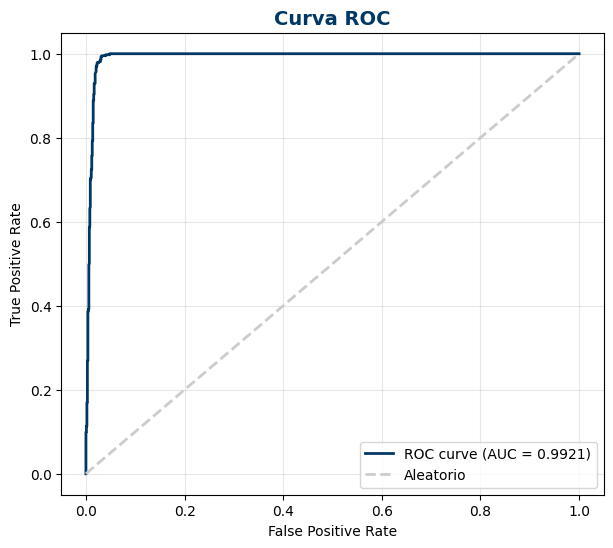

ROC AUC Score: 0.9921


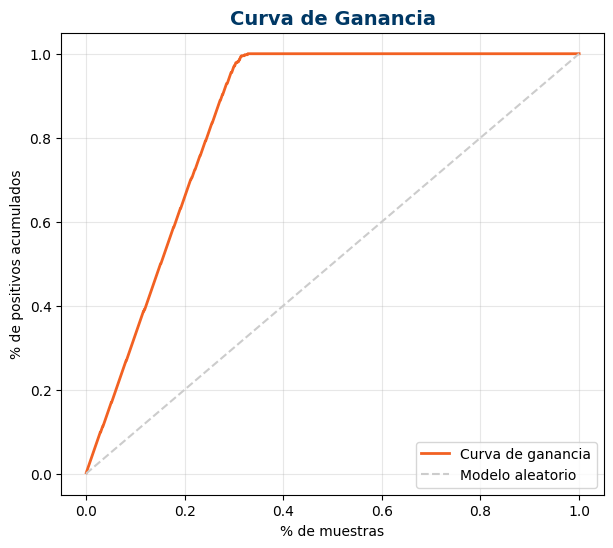

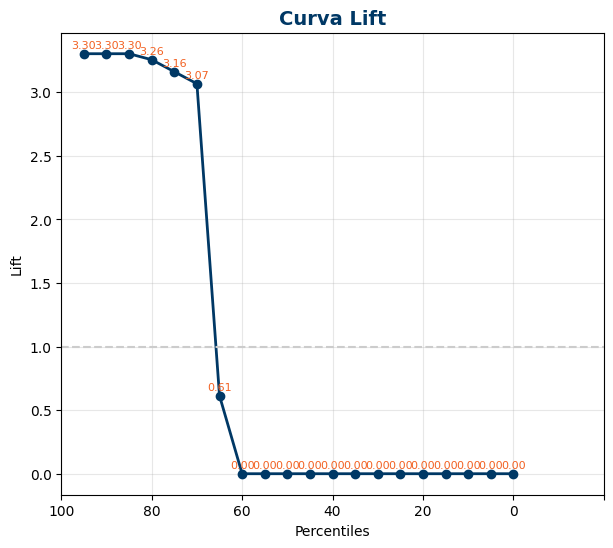

In [54]:
# =====================
# Predicciones
# =====================
y_proba = model.predict_proba(X_test_enc)[:, 1] 
y_proba_train = model.predict_proba(X_train_enc)[:, 1] 
y_pred = model.predict(X_test_enc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")


# =====================
# Curva de Ganancia
# =====================
def plot_gain(y_true, y_proba):
    data = list(zip(y_true, y_proba))
    data = sorted(data, key=lambda x: x[1], reverse=True)
    y_sorted = np.array([d[0] for d in data])

    cum_gains = np.cumsum(y_sorted) / sum(y_sorted)
    perc_samples = np.arange(1, len(y_sorted)+1) / len(y_sorted)

    plt.figure(figsize=(7,6))
    plt.plot(perc_samples, cum_gains, color=ufd_orange, lw=2, label="Curva de ganancia")
    plt.plot([0,1], [0,1], linestyle="--", color=ufd_gray, label="Modelo aleatorio")

    # Estilo
    plt.grid(alpha=0.3)
    plt.xlabel("% de muestras")
    plt.ylabel("% de positivos acumulados")
    plt.title("Curva de Ganancia", fontsize=14, weight="bold", color=ufd_blue)
    plt.legend()
    plt.show()

plot_gain(y_test, y_proba)


# =====================
# Curva Lift
# =====================
def plot_lift(y_true, y_proba, bins=10):
    data = list(zip(y_true, y_proba))
    data = sorted(data, key=lambda x: x[1], reverse=True)
    y_sorted = np.array([d[0] for d in data])

    total_positives_rate = sum(y_sorted) / len(y_sorted)
    group_size = len(y_sorted) // bins
    lift = []

    for i in range(bins):
        start = i * group_size
        end = (i+1) * group_size if i < bins-1 else len(y_sorted)
        group = y_sorted[start:end]
        group_rate = sum(group) / len(group)
        lift.append(group_rate / total_positives_rate)

    # Percentiles crecientes (para graficar normalmente)
    percentiles = list(range(0, 101, int(100/bins)))[1:]  

    plt.figure(figsize=(7,6))
    plt.plot(percentiles, lift, marker="o", color=ufd_blue, lw=2)

    # Etiquetas con valores en cada punto
    for x, val in zip(percentiles, lift):
        plt.text(x, val+0.04, f"{val:.2f}", ha="center", fontsize=8, color=ufd_orange)

    plt.axhline(1, color=ufd_gray, linestyle="--")
    plt.grid(alpha=0.3)
    plt.xlabel("Percentiles")
    plt.ylabel("Lift")
    plt.title("Curva Lift", fontsize=14, weight="bold", color=ufd_blue)

    # Cambiar etiquetas del eje X: 100 → 0
    ticks = plt.xticks()[0]
    new_labels = [str(100 - int(t)) if t >= 0 and t <= 100 else "" for t in ticks]
    plt.xticks(ticks, new_labels)

    plt.show()

# Ejemplo
plot_lift(y_test, y_proba, bins=20)

In [36]:
y_proba

array([3.1058505e-04, 5.4443767e-04, 9.9575055e-01, ..., 2.0966766e-04,
       8.5697620e-04, 1.4843384e-04], shape=(1441,), dtype=float32)

In [37]:
final_df.shape

(7201, 1004)

In [38]:
final_df["target"].value_counts()

target
0.0    5083
1.0    2118
Name: count, dtype: int64

In [39]:
# First, get the indices of the test set in final_df
test_indices = X_test.index
train_indices = X_train.index

# Assign the predicted probabilities to the correct rows
final_df.loc[test_indices, "xgb_pred_proba"] = y_proba
final_df.loc[train_indices, "xgb_pred_proba"] = y_proba_train

In [40]:
final_df

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos,target,anomaly_dbscan,anomaly_iso,reconstruction_error,anomaly_autoencoder,fraude_score_no_supervisado,fraude_score_no_supervisado_norm,xgb_pred_proba
0,ES0022000001000008QR1P,SAG0185769835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,97.26,0.00,1.0,True,False,0.085053,False,1.085053,0.000228,0.978933
1,ES0022000001000074HK1P,ZIV0049764171,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,95.89,0.00,0.0,True,False,0.026311,False,1.026311,0.000050,0.000337
2,ES0022000001001335GV1P,SAG0175667095,0.0,0.0,0.0,0.0,0.0,0.0,29.0,0.0,...,87.37,0.02,0.0,True,False,0.121765,False,1.121765,0.000339,0.000414
3,ES0022000001001659HL1P,SAG0185750027,0.0,0.0,0.0,0.0,28.0,0.0,28.0,28.0,...,97.69,0.00,0.0,True,False,0.259683,False,1.259683,0.000757,0.000188
4,ES0022000001003743VX1P,SOG0100065879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,97.26,0.01,0.0,True,False,0.153162,False,1.153162,0.000434,0.000421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7328,ES0390000008387554LQ1P,SOG0940285550,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,...,84.72,0.00,1.0,True,False,0.453510,False,1.453510,0.001345,0.992822
7329,ES0390000008771580HB1P,ZIV0047338977,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,95.31,0.03,1.0,True,False,0.564833,False,1.564833,0.001682,0.868693
7330,ES0390000008871552HW1P,SOG0940278595,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,97.69,0.13,1.0,True,False,0.563134,False,1.563134,0.001677,0.959913
7331,ES0390000008989303PQ1P,SAG0231807042,28.0,28.0,0.0,28.0,0.0,0.0,28.0,56.0,...,0.72,0.10,1.0,True,False,0.223467,False,1.223467,0.000647,0.866343


In [60]:
final_df["final_scoring"] = final_df["fraude_score_no_supervisado_norm"]*0.3 + final_df["xgb_pred_proba"]*0.7

### Feature importance

                                               feature  importance
164   porcentaje_calidad_datos_semana_pasada_correctos  363.181732
162   porcentaje_calidad_datos_semana_actual_correctos  236.583237
153                          consumo_min_anio_anterior   25.200392
155                         consumo_zero_anio_anterior   21.566412
165  porcentaje_calidad_datos_misma_semana_anio_pas...   16.554512
141                    consumo_umbral_trimestre_pasado   13.843266
133                      consumo_zero_trimestre_actual   10.220746
26                         cnt_eventos_mes_actual_6_NA    9.323701
168      porcentaje_calidad_datos_mes_pasado_correctos    9.110327
78                        cnt_eventos_anio_pasado_2_14    8.710769
143                consumo_media_trimestre_anio_pasado    8.532171
150                          consumo_count_anio_actual    7.957324
10                      cnt_eventos_semana_pasada_6_NA    7.599444
17                         cnt_eventos_mes_actual_1_30    7.32

<Figure size 1000x800 with 0 Axes>

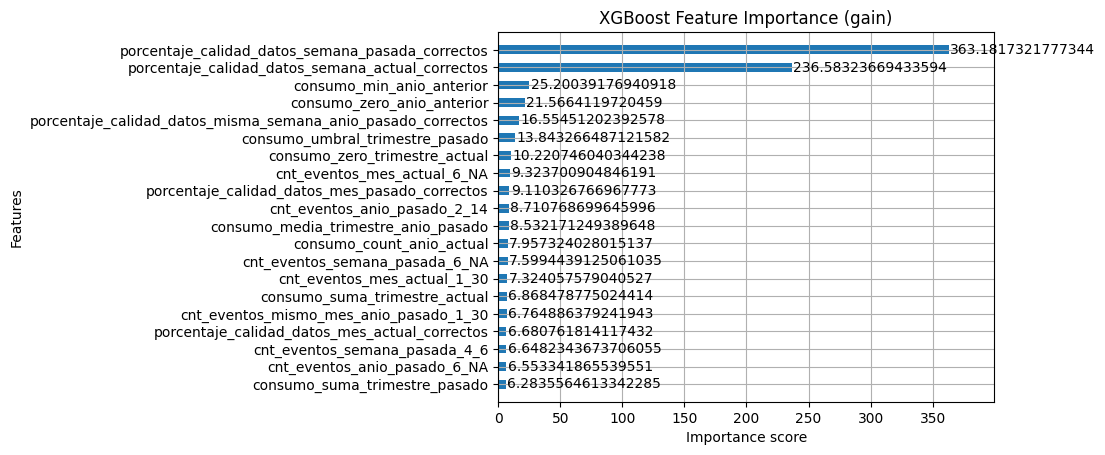

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import plot_importance

# =====================
# Feature Importance con el modelo entrenado
# =====================
# Importancia como "gain" (lo más interpretado: cuánto aporta cada feature en promedio)
importance_dict = model.get_booster().get_score(importance_type='gain')

# Convertir a DataFrame ordenado
importance_df = pd.DataFrame({
    'feature': list(importance_dict.keys()),
    'importance': list(importance_dict.values())
}).sort_values(by='importance', ascending=False)

print(importance_df.head(20))  # Top 20 features

# =====================
# Plot con xgboost (rápido)
# =====================
plt.figure(figsize=(10, 8))
plot_importance(model, importance_type='gain', max_num_features=20, height=0.5, grid=True)
plt.title("XGBoost Feature Importance (gain)")
plt.show()

In [63]:
final_df["target"] = final_df["target"].astype(int)

(
    final_df[["cups_sgc", "cnt_id", "fraude_score_no_supervisado_norm", "xgb_pred_proba", "final_scoring", "target"]]
    .to_csv("final_results.csv", index=False)
)